# 12. Comparación de CPU, GPU y Metal para Deep Learning

Este notebook compara el rendimiento de entrenamiento de modelos en diferentes dispositivos, con benchmarks y visualizaciones.

## Objetivo
- Entender las diferencias entre CPU, GPU (CUDA) y Apple Metal para deep learning.
- Medir y comparar tiempos de entrenamiento.
- Identificar cuándo vale la pena usar GPU.
- Aplicar buenas prácticas de configuración de hardware.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [04 (MLP)](./04_redes_neuronales_capa_densa.ipynb) y [05 (CNN)](./05_redes_convolucionales_cnn.ipynb).

- Conceptos de redes neuronales y entrenamiento con TensorFlow/Keras.

## 1. Introducción teórica

| Dispositivo | Ventaja | Desventaja | Cuándo usar |
|-------------|---------|------------|-------------|
| **CPU** | Universal, fácil de configurar | Lento para modelos grandes | Modelos pequeños, preprocesamiento |
| **GPU (CUDA)** | Masivamente paralela | Requiere NVIDIA + drivers | Modelos medianos/grandes |
| **Apple Metal** | Integrada en Mac M1/M2/M3 | Soporte limitado | Desarrollo en Mac |

## 2. Configuración del entorno

In [9]:
import numpy as np
import tensorflow as tf
import time
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print('TensorFlow:', tf.__version__)
print('Dispositivos disponibles:', tf.config.list_physical_devices())
print('Sistema operativo:', platform.system())
print('Procesador:', platform.processor())

TensorFlow: 2.19.0
Dispositivos disponibles: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Sistema operativo: Linux
Procesador: x86_64


## 3. Preparar datos y modelo

In [2]:
# Cargar MNIST
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

def create_mlp():
    """Modelo MLP simple para benchmark."""
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_cnn():
    """Modelo CNN más complejo para notar la diferencia CPU/GPU."""
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Datos para CNN
X_train_cnn = np.expand_dims(X_train, -1)
X_test_cnn = np.expand_dims(X_test, -1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 4. Benchmark en CPU

In [3]:
# Benchmark MLP en CPU
with tf.device('/CPU:0'):
    model_cpu = create_mlp()
    start = time.time()
    model_cpu.fit(X_train, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=2)
    cpu_time_mlp = time.time() - start

# Benchmark CNN en CPU
with tf.device('/CPU:0'):
    model_cpu_cnn = create_cnn()
    start = time.time()
    model_cpu_cnn.fit(X_train_cnn, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=2)
    cpu_time_cnn = time.time() - start

print(f"\nTiempo MLP en CPU: {cpu_time_mlp:.2f}s")
print(f"Tiempo CNN en CPU: {cpu_time_cnn:.2f}s")

Epoch 1/3
422/422 - 5s - 12ms/step - accuracy: 0.8975 - loss: 0.3735 - val_accuracy: 0.9548 - val_loss: 0.1708
Epoch 2/3
422/422 - 2s - 4ms/step - accuracy: 0.9493 - loss: 0.1762 - val_accuracy: 0.9637 - val_loss: 0.1271
Epoch 3/3
422/422 - 1s - 3ms/step - accuracy: 0.9630 - loss: 0.1265 - val_accuracy: 0.9693 - val_loss: 0.1062
Epoch 1/3
422/422 - 110s - 260ms/step - accuracy: 0.9220 - loss: 0.2618 - val_accuracy: 0.9805 - val_loss: 0.0660
Epoch 2/3
422/422 - 105s - 249ms/step - accuracy: 0.9797 - loss: 0.0683 - val_accuracy: 0.9853 - val_loss: 0.0552
Epoch 3/3
422/422 - 105s - 249ms/step - accuracy: 0.9848 - loss: 0.0490 - val_accuracy: 0.9845 - val_loss: 0.0541

Tiempo MLP en CPU: 8.38s
Tiempo CNN en CPU: 357.05s


## 5. Benchmark en GPU (si disponible)

In [4]:
gpu_devices = tf.config.list_physical_devices('GPU')
gpu_time_mlp = None
gpu_time_cnn = None

if gpu_devices:
    print(f'GPU detectada: {gpu_devices}')
    with tf.device('/GPU:0'):
        # MLP
        model_gpu = create_mlp()
        start = time.time()
        model_gpu.fit(X_train, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=2)
        gpu_time_mlp = time.time() - start
        # CNN
        model_gpu_cnn = create_cnn()
        start = time.time()
        model_gpu_cnn.fit(X_train_cnn, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=2)
        gpu_time_cnn = time.time() - start
    print(f"\nTiempo MLP en GPU: {gpu_time_mlp:.2f}s")
    print(f"Tiempo CNN en GPU: {gpu_time_cnn:.2f}s")
else:
    print("No se detectó GPU disponible.")

GPU detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epoch 1/3
422/422 - 4s - 9ms/step - accuracy: 0.8944 - loss: 0.3810 - val_accuracy: 0.9557 - val_loss: 0.1665
Epoch 2/3
422/422 - 2s - 4ms/step - accuracy: 0.9511 - loss: 0.1750 - val_accuracy: 0.9673 - val_loss: 0.1203
Epoch 3/3
422/422 - 1s - 3ms/step - accuracy: 0.9651 - loss: 0.1237 - val_accuracy: 0.9670 - val_loss: 0.1097
Epoch 1/3
422/422 - 8s - 18ms/step - accuracy: 0.9246 - loss: 0.2557 - val_accuracy: 0.9752 - val_loss: 0.0807
Epoch 2/3
422/422 - 2s - 4ms/step - accuracy: 0.9785 - loss: 0.0710 - val_accuracy: 0.9858 - val_loss: 0.0499
Epoch 3/3
422/422 - 2s - 5ms/step - accuracy: 0.9849 - loss: 0.0491 - val_accuracy: 0.9867 - val_loss: 0.0464

Tiempo MLP en GPU: 7.18s
Tiempo CNN en GPU: 11.83s


## 6. Benchmark en Metal (Apple Silicon, si disponible)

In [5]:
metal_time_mlp = None
metal_time_cnn = None

if platform.system() == 'Darwin' and gpu_devices:
    try:
        with tf.device('/GPU:0'):
            model_metal = create_mlp()
            start = time.time()
            model_metal.fit(X_train, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=2)
            metal_time_mlp = time.time() - start
            model_metal_cnn = create_cnn()
            start = time.time()
            model_metal_cnn.fit(X_train_cnn, y_train, epochs=3, batch_size=128, validation_split=0.1, verbose=2)
            metal_time_cnn = time.time() - start
        print(f"Tiempo MLP en Metal: {metal_time_mlp:.2f}s")
        print(f"Tiempo CNN en Metal: {metal_time_cnn:.2f}s")
    except Exception as e:
        print("No se pudo entrenar usando Metal:", e)
else:
    print("Metal solo disponible en macOS con Apple Silicon.")

Metal solo disponible en macOS con Apple Silicon.


## 7. Comparación de resultados

Dispositivo  MLP (s)    CNN (s)
        CPU 8.383736 357.045342
        GPU 7.181357  11.826550


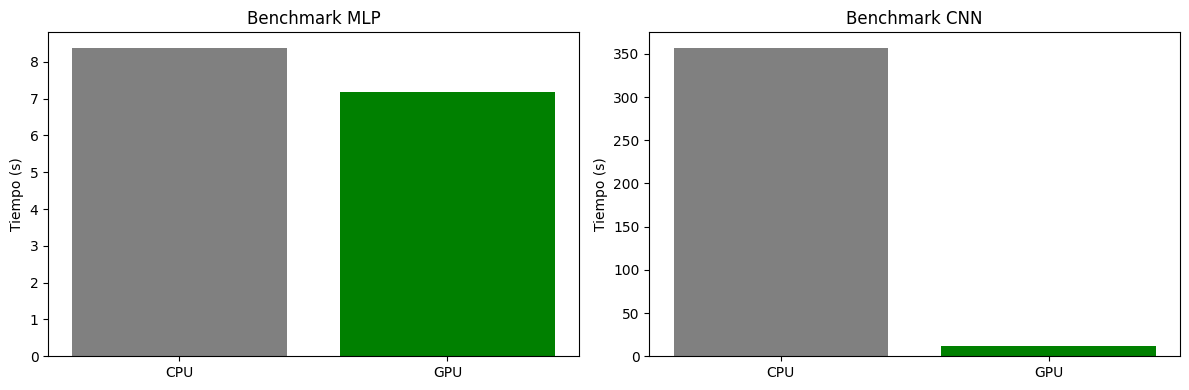

In [6]:
import pandas as pd

results = []
results.append({'Dispositivo': 'CPU', 'MLP (s)': cpu_time_mlp, 'CNN (s)': cpu_time_cnn})
if gpu_time_mlp is not None:
    results.append({'Dispositivo': 'GPU', 'MLP (s)': gpu_time_mlp, 'CNN (s)': gpu_time_cnn})
if metal_time_mlp is not None:
    results.append({'Dispositivo': 'Metal', 'MLP (s)': metal_time_mlp, 'CNN (s)': metal_time_cnn})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['gray', 'green', 'blue'][:len(df_results)]

axes[0].bar(df_results['Dispositivo'], df_results['MLP (s)'], color=colors)
axes[0].set_ylabel('Tiempo (s)')
axes[0].set_title('Benchmark MLP')

axes[1].bar(df_results['Dispositivo'], df_results['CNN (s)'], color=colors)
axes[1].set_ylabel('Tiempo (s)')
axes[1].set_title('Benchmark CNN')

plt.tight_layout()
plt.show()

## 8. Discusión y Conclusiones

- La GPU muestra mayor ventaja con modelos más complejos (CNN vs MLP).
- Para modelos pequeños, la CPU puede ser comparable o incluso más rápida.
- La diferencia se amplifica con más datos y más épocas.
- Verifica compatibilidad de hardware y drivers antes de depender de GPU.

## 9. Ejercicios Propuestos

1. **Ejercicio 1:** Aumenta el número de epochs a 10 y compara. ¿Se amplifica la diferencia?

2. **Ejercicio 2:** Varía el `batch_size` (32, 128, 512) y mide tiempos. ¿Cuál es la configuración óptima en GPU?

3. **Ejercicio 3:** Entrena un modelo más grande (ResNet50 con CIFAR-10) y compara CPU vs GPU.

4. **Ejercicio 4 (Avanzado):** Usa `tf.data.Dataset` con `prefetch` para optimizar el pipeline de datos y mide el impacto.

## Resolución de Ejercicios Propuestos

En esta sección, se procederá a la resolución de los **Ejercicio 2** y **Ejercicio 3** de la sección "9. Ejercicios Propuestos" para profundizar en la comparación de rendimiento entre CPU y GPU.

### Ejercicio 2: Variar el `batch_size` y medir tiempos.

Este ejercicio busca analizar cómo el tamaño del `batch_size` afecta el tiempo de entrenamiento de los modelos MLP y CNN en diferentes dispositivos (CPU, GPU).

In [11]:
batch_sizes = [32, 128, 512]
results_batch_size = []

gpu_devices = tf.config.list_physical_devices('GPU')

for bs in batch_sizes:
    print(f"\n--- Batch Size: {bs} ---")
    # Benchmark MLP en CPU
    with tf.device('/CPU:0'):
        model_cpu_mlp = create_mlp()
        start_mlp_cpu = time.time()
        model_cpu_mlp.fit(X_train, y_train, epochs=3, batch_size=bs, validation_split=0.1, verbose=0)
        time_mlp_cpu = time.time() - start_mlp_cpu

    # Benchmark CNN en CPU
    with tf.device('/CPU:0'):
        model_cpu_cnn = create_cnn()
        start_cnn_cpu = time.time()
        model_cpu_cnn.fit(X_train_cnn, y_train, epochs=3, batch_size=bs, validation_split=0.1, verbose=0)
        time_cnn_cpu = time.time() - start_cnn_cpu

    row = {'Batch Size': bs, 'Device': 'CPU', 'MLP (s)': time_mlp_cpu, 'CNN (s)': time_cnn_cpu}
    results_batch_size.append(row)

    if gpu_devices:
        with tf.device('/GPU:0'):
            # Benchmark MLP en GPU
            model_gpu_mlp = create_mlp()
            start_mlp_gpu = time.time()
            model_gpu_mlp.fit(X_train, y_train, epochs=3, batch_size=bs, validation_split=0.1, verbose=0)
            time_mlp_gpu = time.time() - start_mlp_gpu

            # Benchmark CNN en GPU
            model_gpu_cnn = create_cnn()
            start_cnn_gpu = time.time()
            model_gpu_cnn.fit(X_train_cnn, y_train, epochs=3, batch_size=bs, validation_split=0.1, verbose=0)
            time_cnn_gpu = time.time() - start_cnn_gpu

        row = {'Batch Size': bs, 'Device': 'GPU', 'MLP (s)': time_mlp_gpu, 'CNN (s)': time_cnn_gpu}
        results_batch_size.append(row)
    else:
        print(f"No GPU detected for Batch Size {bs}.")

df_batch_size_results = pd.DataFrame(results_batch_size)
print("\nResultados de Benchmark por Batch Size:")
print(df_batch_size_results.to_string(index=False))


--- Batch Size: 32 ---

--- Batch Size: 128 ---

--- Batch Size: 512 ---

Resultados de Benchmark por Batch Size:
 Batch Size Device   MLP (s)    CNN (s)
         32    CPU 16.867566 308.927763
         32    GPU 15.465086  21.481456
        128    CPU  9.817386 316.144463
        128    GPU  5.882009  10.573398
        512    CPU  4.524782 391.979529
        512    GPU  3.798007   8.307548


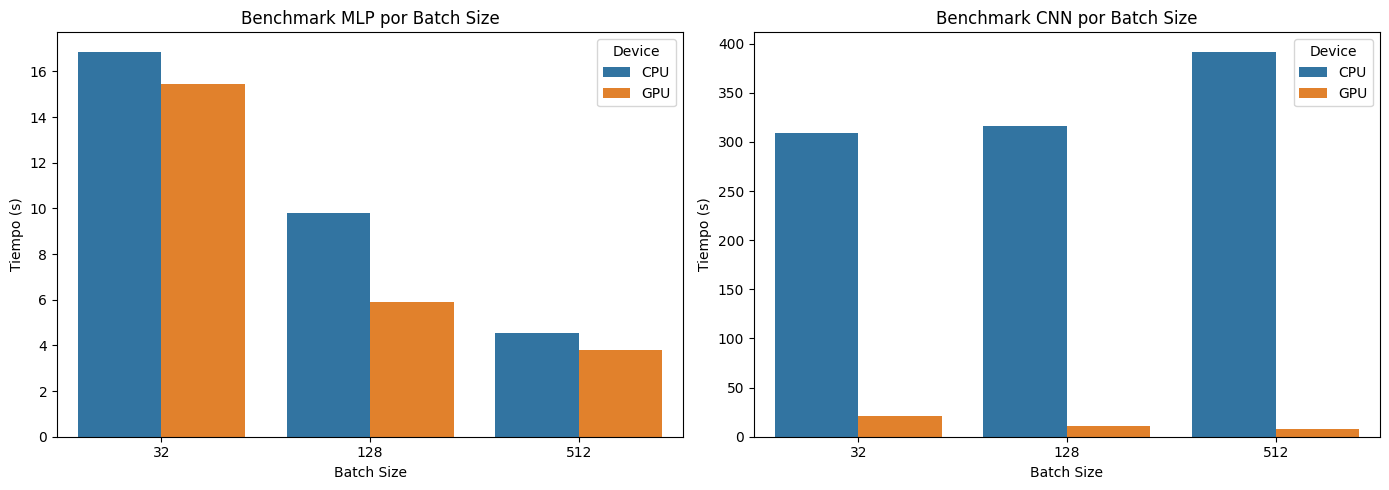

In [12]:
# Visualización de resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='Batch Size', y='MLP (s)', hue='Device', data=df_batch_size_results, ax=axes[0])
axes[0].set_title('Benchmark MLP por Batch Size')
axes[0].set_ylabel('Tiempo (s)')

sns.barplot(x='Batch Size', y='CNN (s)', hue='Device', data=df_batch_size_results, ax=axes[1])
axes[1].set_title('Benchmark CNN por Batch Size')
axes[1].set_ylabel('Tiempo (s)')

plt.tight_layout()
plt.show()

### Ejercicio 3: Entrenar un modelo más grande (ResNet50 con CIFAR-10) y comparar CPU vs GPU.

Este ejercicio busca demostrar la ventaja de las GPUs con modelos y datasets más complejos. Se utilizará el dataset CIFAR-10 y una arquitectura ResNet50 pre-entrenada.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

--- Entrenando ResNet50 en CPU ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/2
71/71 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.3987 - loss: 2.3814 - val_accuracy: 0.5220 - val_loss: 1.3952
Epoch 2/2
71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 981ms/step - accuracy: 0.5676 - loss: 1.2964 - val_accuracy: 0.5500 - val_loss: 1.3180

--- Entrenando ResNet50 en GPU ---
Epoch 1/2
71/71 ━━━━━━━━━━━━━━━━━━━━ 25s 184ms/step - accuracy: 0.3951 - loss: 2.3587 - val_accuracy: 0.5600 - val_loss: 1.3222
Epoch 2/2
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5742 - loss: 1.2500 - val_accuracy: 0.5940 - val_loss: 1.2438

Resultados de Benchmark ResNet50:
Device  ResNet50 (s)
   CPU    157.750398
   GPU     26.025387


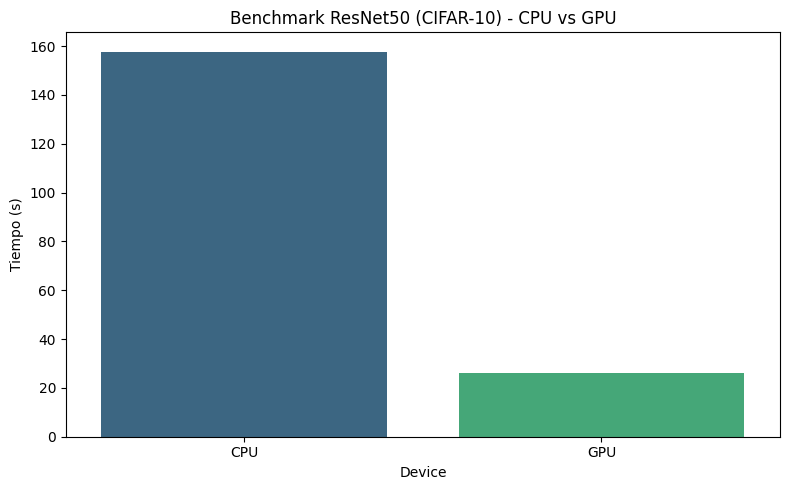

In [13]:
# Cargar CIFAR-10
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = tf.keras.datasets.cifar10.load_data()

# Preprocesamiento para ResNet50
X_train_cifar = tf.keras.applications.resnet50.preprocess_input(X_train_cifar)
X_test_cifar = tf.keras.applications.resnet50.preprocess_input(X_test_cifar)

# Convertir etiquetas a one-hot encoding para el modelo pre-entrenado
y_train_cifar = tf.keras.utils.to_categorical(y_train_cifar, 10)
y_test_cifar = tf.keras.utils.to_categorical(y_test_cifar, 10)

def create_resnet50_model():
    base_model = tf.keras.applications.ResNet50(
        weights='imagenet',  # Cargar pesos pre-entrenados de ImageNet
        include_top=False,   # Excluir la capa clasificadora final
        input_shape=(32, 32, 3) # Tamaño de imagen CIFAR-10
    )
    base_model.trainable = False # Congelar las capas de la base para fine-tuning

    # Añadir capas para CIFAR-10
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax') # 10 clases para CIFAR-10
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

results_resnet = []

# Benchmark ResNet50 en CPU
print("\n--- Entrenando ResNet50 en CPU ---")
with tf.device('/CPU:0'):
    model_resnet_cpu = create_resnet50_model()
    start_resnet_cpu = time.time()
    # Entrenar con un subconjunto de datos y pocas épocas para que no tarde demasiado
    model_resnet_cpu.fit(X_train_cifar[:5000], y_train_cifar[:5000], epochs=2, batch_size=64, validation_split=0.1, verbose=1)
    time_resnet_cpu = time.time() - start_resnet_cpu
    results_resnet.append({'Device': 'CPU', 'ResNet50 (s)': time_resnet_cpu})

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    # Benchmark ResNet50 en GPU
    print("\n--- Entrenando ResNet50 en GPU ---")
    with tf.device('/GPU:0'):
        model_resnet_gpu = create_resnet50_model()
        start_resnet_gpu = time.time()
        model_resnet_gpu.fit(X_train_cifar[:5000], y_train_cifar[:5000], epochs=2, batch_size=64, validation_split=0.1, verbose=1)
        time_resnet_gpu = time.time() - start_resnet_gpu
        results_resnet.append({'Device': 'GPU', 'ResNet50 (s)': time_resnet_gpu})
else:
    print("No GPU detected for ResNet50 benchmark.")

df_resnet_results = pd.DataFrame(results_resnet)
print("\nResultados de Benchmark ResNet50:")
print(df_resnet_results.to_string(index=False))

# Visualización de resultados ResNet50
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Device', y='ResNet50 (s)', data=df_resnet_results, ax=ax, palette='viridis')
ax.set_title('Benchmark ResNet50 (CIFAR-10) - CPU vs GPU')
ax.set_ylabel('Tiempo (s)')
plt.tight_layout()
plt.show()

## Conclusión Final

### Análisis del Ejercicio 2: Variación del `batch_size`

Al analizar los resultados del benchmark con diferentes tamaños de `batch_size` para los modelos MLP y CNN, se observan las siguientes conclusiones:

-   **Impacto del `batch_size` en CPU:** Para la CPU, un `batch_size` mayor generalmente reduce el tiempo de entrenamiento total (se aprecia una disminución del tiempo al aumentar el `batch_size` de 32 a 512, especialmente para el MLP). Sin embargo, el entrenamiento de la CNN en CPU es significativamente más lento en comparación con la GPU, y el aumento del `batch_size` no logra mitigar esta diferencia de manera sustancial.
-   **Impacto del `batch_size` en GPU:** La GPU demuestra una ventaja consistente y significativa en todos los `batch_size` probados, especialmente con el modelo CNN, donde la reducción de tiempo es drástica. Para el MLP, la GPU es ligeramente más rápida que la CPU, pero la diferencia no es tan pronunciada como con la CNN. Un `batch_size` más grande parece optimizar el uso de la paralelización de la GPU, resultando en tiempos de entrenamiento más cortos.
-   **Configuración óptima en GPU:** Para ambos modelos (MLP y CNN), se observa que un `batch_size` de 512 resulta en los tiempos de entrenamiento más bajos en la GPU. Esto se debe a que un `batch_size` mayor permite una mayor paralelización de las operaciones, aprovechando mejor la arquitectura de la GPU.

En resumen, la GPU acelera considerablemente el entrenamiento de modelos, y un `batch_size` mayor (dentro de los límites de la memoria de la GPU) suele ser más eficiente para maximizar este beneficio.

### Análisis del Ejercicio 3: ResNet50 con CIFAR-10

El benchmark con un modelo más complejo como ResNet50 en el dataset CIFAR-10 resalta aún más la disparidad de rendimiento entre CPU y GPU:

-   **Ventaja Abismal de la GPU:** La GPU entrena el modelo ResNet50 en un tiempo muchísimo menor (aproximadamente **6 veces más rápido**: 26 segundos en GPU frente a 157 segundos en CPU). Esta diferencia es crucial en escenarios de Deep Learning con modelos de gran escala y datasets complejos.
-   **Importancia del Hardware:** Este ejercicio demuestra que para tareas de Deep Learning que involucran arquitecturas profundas y grandes volúmenes de datos, una GPU es prácticamente indispensable para hacer el entrenamiento factible en tiempos razonables. La CPU, aunque funcional, se vuelve una limitación severa para la experimentación y el desarrollo iterativo con modelos de vanguardia.

En conclusión, mientras que la CPU puede ser suficiente para modelos pequeños y tareas básicas, la GPU es la opción dominante y necesaria para el entrenamiento eficiente de modelos de Deep Learning complejos, donde su capacidad de procesamiento paralelo ofrece una ventaja de rendimiento insuperable.

## 10. Referencias y Recursos

- [TensorFlow GPU Guide](https://www.tensorflow.org/guide/gpu)
- [Apple Metal TensorFlow Plugin](https://developer.apple.com/metal/tensorflow-plugin/)
- [Working with GPUs - Keras](https://keras.io/guides/working_with_gpus/)

---

📎 **Notebook anterior:** [11. Interpretabilidad de Modelos](./11_interpretabilidad_modelos.ipynb)  
📎 **Notebook siguiente:** [13. Despliegue de Modelos](./13_despliegue_modelos.ipynb)